# Tutorial 10a: Non-Sequential & Illumination

Most Optiland tutorials use the **sequential** engine: light passes through a known,
ordered list of surfaces toward a single image plane. That is the right tool for
imaging design. But many problems are not imaging problems:

* How uniform is the light an LED throws onto a screen?
* Where does stray light and how many *ghost reflections* land on my sensor?
* How efficient is a non-imaging concentrator or light pipe?

For these, Optiland ships a differentiable **non-sequential (NSQ)** engine. Rays
propagate freely through a 3-D scene and interact with surfaces **in any order** —
reflecting, refracting, and scattering wherever they go. This tutorial is a short
on-ramp; the [NSQ gallery](../gallery/nonsequential.rst) is the deep dive.

> **Two engines, two jobs.** NSQ runs forward on **NumPy** (fast, 1e7+ rays — the
> production illumination/stray-light path, used here) and differentiably on
> **PyTorch** (optimize a scene with `loss.backward()`). See gallery notebook 11.


## 1. A small illumination scene

An NSQ model is an `NSQScene` holding **sources**, **components**, and **detectors**,
each placed with a `CoordinateSystem`. Units: wavelengths in **µm**, positions in
**mm**, angles in **radians** (config fields ending in `_deg` are degrees).

Here we throw a rectangular, LED-like `ExtendedSource` onto a screen and read the
irradiance footprint — no lens, just free propagation.


Flux launched  : 1.000 W
Flux on screen : 0.666 W  (133,123 rays)


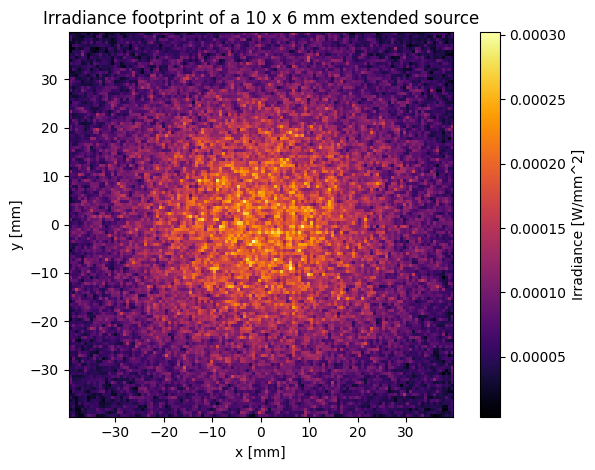

In [1]:
import matplotlib.pyplot as plt

from optiland.coordinate_system import CoordinateSystem
from optiland.nonsequential import (
    NSQScene, Spectrum, ExtendedSourceConfig, IrradianceDetectorConfig,
)

scene = NSQScene()
spec = Spectrum.monochromatic(0.55)          # 550 nm (wavelengths are in micrometres)

# A 10 x 6 mm extended (LED-like) emitter into a 60-degree half-angle cone
scene.add_source(
    'LED', CoordinateSystem(z=0),
    ExtendedSourceConfig(spectrum=spec, total_flux=1.0,
                         width=10, height=6, half_angle_deg=60),
)
# A screen 40 mm downstream
scene.add_detector(
    'screen', CoordinateSystem(z=40),
    IrradianceDetectorConfig(width=80, height=80, num_pixels_x=128, num_pixels_y=128),
)

# Forward trace on the NumPy engine
result = scene.trace(num_rays=200_000, max_depth=16, seed=0)

screen = result.detectors['screen']
print(f"Flux launched  : {result.total_flux_in:.3f} W")
print(f"Flux on screen : {screen.total_flux:.3f} W  ({screen.num_rays_hit:,} rays)")

fig = screen.plot(cmap='inferno')
plt.title('Irradiance footprint of a 10 x 6 mm extended source')
plt.tight_layout()
plt.show()


## 2. Reading detectors

`scene.trace(...)` returns a `SimulationResult`. Its `.detectors` dict is keyed by the
names you assigned; each value is a result object — here an `IrradianceMap` with
`.irradiance` (a W/mm² pixel array), `.total_flux`, `.num_rays_hit`, and a `.plot()`
helper. The `SimulationResult` itself also carries flux-conservation bookkeeping
(`total_flux_in`, `total_flux_detected`, `num_rays_escaped`, `num_rays_depth_killed`, …).

Other detectors record different physics: `FarFieldDetector` (angular intensity),
`SpectralDetector` (per-wavelength), and `RayDatabaseDetector` (every ray's full
phase-space record). They are covered in gallery notebook 04.


## 3. Already have a lens? Convert it for stray-light analysis

The fastest on-ramp for existing Optiland users: take any sequential `Optic` and
convert it to an `NSQScene` in **one line**. `sequential_to_nonsequential` maps
singlets to `Lens`, cemented doublets to `Doublet`, and the image surface to an
`IrradianceDetector`. Because NSQ models Fresnel reflections at every uncoated
interface, the trace reveals **ghost reflections** that the sequential engine never
shows (the sequential engine always transmits 100% at an uncoated surface).

Conversion is never perfectly lossless — a sequential system doesn't carry
everything NSQ needs (explicit apertures, mirror reflectance, coatings), so the
converter has to default, estimate, or drop what's missing. Every such decision is
recorded on the returned scene as `scene.conversion_report`, a structured record
you can inspect instead of having to parse warning text — read it before trusting
a converted trace.


Bare Fresnel, no sequential coating found (6): L1.front, L1.back, L3.front, L3.back, L5.front, L5.back
Apertures estimated (not explicitly set) (6): L1.front, L1.back, L3.front, L3.back, L5.front, L5.back


NSQ trace diagnostics:
  depth_truncated_flux_fraction: 0.0000%
  rr_killed_flux_fraction:       0.0000%
  flux_conservation_error:       0.0000%
  unreached_geometry:            none
  medium_stack_underflows:       0
  split_budget_saturated:        False
  detectors:
    D1: 54478 hits, 0.21 mean hits/pixel [undersampled]
Warnings:
  - Detector 'D1' is undersampled: 0.2 mean hits/pixel (< 10), shot noise dominates the map; ~192,476,963 rays would bring it to ~5% relative error.


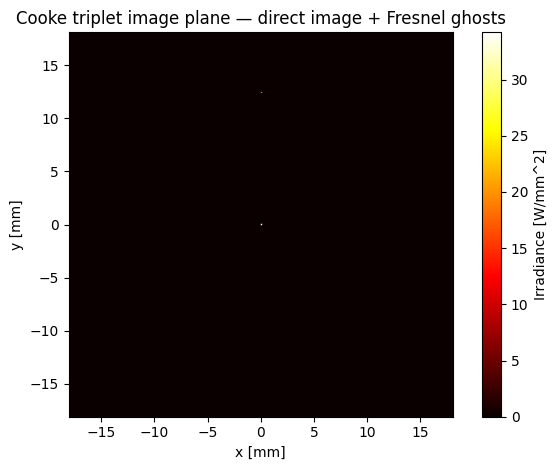


Image-plane flux: 1.6329 W from 54,478 rays


In [2]:
import warnings

from optiland.samples.objectives import CookeTriplet
from optiland.nonsequential import sequential_to_nonsequential

optic = CookeTriplet()

with warnings.catch_warnings():
    # The converter also raises a plain warning for the same information;
    # scene.conversion_report below is the structured version of it, so we
    # silence the warning and inspect the report instead.
    warnings.simplefilter('ignore')
    ghost_scene = sequential_to_nonsequential(optic)

print(ghost_scene.conversion_report.summary())

# max_depth high enough to let rays bounce between surfaces and form ghosts
result = ghost_scene.trace(num_rays=100_000, max_depth=32, seed=0)

# Ghost flux is faint by construction (a few percent of the beam, several
# bounces deep), so always check result.report() before trusting the numbers:
# a converted, multi-bounce scene like this one is exactly where an
# undersampled detector or truncated-depth flux would otherwise go unnoticed.
print(result.report())

det_name = list(result.detectors)[0]         # converter names the image detector
img = result.detectors[det_name]

fig = img.plot(cmap='hot')
plt.title('Cooke triplet image plane — direct image + Fresnel ghosts')
plt.tight_layout()
plt.show()

print(f"\nImage-plane flux: {img.total_flux:.4f} W from {img.num_rays_hit:,} rays")


## Where to go next

This was the teaser. The **[NSQ gallery](../gallery/nonsequential.rst)** is the full
deep dive:

* **01–05** — getting started, ray sources, optical components, detectors & results,
  surface scattering (BSDFs).
* **06–10** — diagnostics, multi-source illumination, stray-light/ghost analysis,
  reflective systems, advanced topics.
* **11 — Differentiable optimization.** Switch to the PyTorch backend and reshape a
  detector's irradiance by optimizing a lens radius via `loss.backward()`.

NSQ is pre-release (never shipped in a tagged Optiland version), so its API may
still change. For the current capability envelope and known limitations (notably
zero visibility gradients), see the canonical
**[NSQ Limitations & Roadmap](../gallery/nonsequential/limitations_and_roadmap.rst)** page.
